# Exploratory Analysis

## Import Libraries

In [1]:
# Import necessary libraries for data analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Read Data

In [2]:
df_library = pd.read_csv('data/music_library.csv')
df_library.head()

,#,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,album_year
0,1,When the Love is Gone,Des Rocs,141,9A,81,2026-03-05,03:20,52,NaN,...,47,0,20,-4,E Minor,4,5iRv1aH4eNai45KfhjtJ6n,USFYZ2557602,Rock,2026
1,2,BURNER PHONE,cleopatrick,136,9A,91,2026-03-05,03:21,42,NaN,...,46,0,30,-5,E Minor,4,1nUC2uuKUl49tDwQ1m4A1J,CAJXF2500023,Rock,2025
2,3,Queen Of Spades,Styx,135,12A,45,2026-03-05,05:41,36,"classic rock, aor, progressive rock",...,12,0,10,-13,C♯/D♭ Minor,4,54g63GAn77x9NcjiLzy7cW,USAM17802305,Rock,1978
3,4,Go Your Own Way,Fleetwood Mac,136,7B,81,2026-03-05,03:38,62,"yacht rock, classic rock, soft rock",...,82,0,10,-12,F Major,4,15rjQH7nTcTomKwfVMd4xl,USWB19900181,Rock,1988
4,5,I Don't Care Anymore - 2016 Remaster,Phil Collins,140,1B,42,2026-03-05,05:05,61,soft rock,...,44,0,0,-8,B Major,4,24IdPCimVnJJDRuB5YSDiS,USRH11509311,Rock,1982


## Analysis

### K-means

In [3]:
# Define a function to cluster a playlist and analyze its features
def cluster_playlist(df_library, playlist_name, features):

    # Helper function to find the best k using silhouette score
    def get_best_k(X_scaled, k_range=(2, 11)):
        scores = {}
        for k in range(k_range[0], k_range[1]):
            km = KMeans(n_clusters=k, n_init=50, random_state=42)
            labels = km.fit_predict(X_scaled)
            scores[k] = silhouette_score(X_scaled, labels)
        best_k = max(scores, key=scores.get)
        return best_k, scores
    
    # Filter the library for the specified playlist
    df_playlist = df_library[df_library['Playlist'] == playlist_name]
    
    # Correlation analysis
    correlation = df_playlist[features].corr()
    
    # Scale features
    X = df_playlist[features].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Find best k
    best_k, scores = get_best_k(X_scaled)
    
    # Run clustering with best k
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # PCA loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=['PC1', 'PC2'],
        index=features
    )
    
    # Plot PCA
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.title(f'{playlist_name} Clusters (k={best_k})')
    plt.tight_layout()
    plt.show()
    
    
    return {
        'correlation': correlation,
        'best_k': best_k,
        'silhouette_scores': scores,
        'n_songs': len(X),
        'clusters': clusters,
        'kmeans': kmeans, 
        'pca_loadings': loadings
    }

In [4]:
# Create a dictionary to store the results for each playlist
playlist_dict = {name: group for name, group in df_library.groupby('Playlist')}
playlist_dict.keys()

dict_keys(['Alternative', 'Pop', 'Rap-R&B', 'Rock'])

Analyzing Alternative playlist...


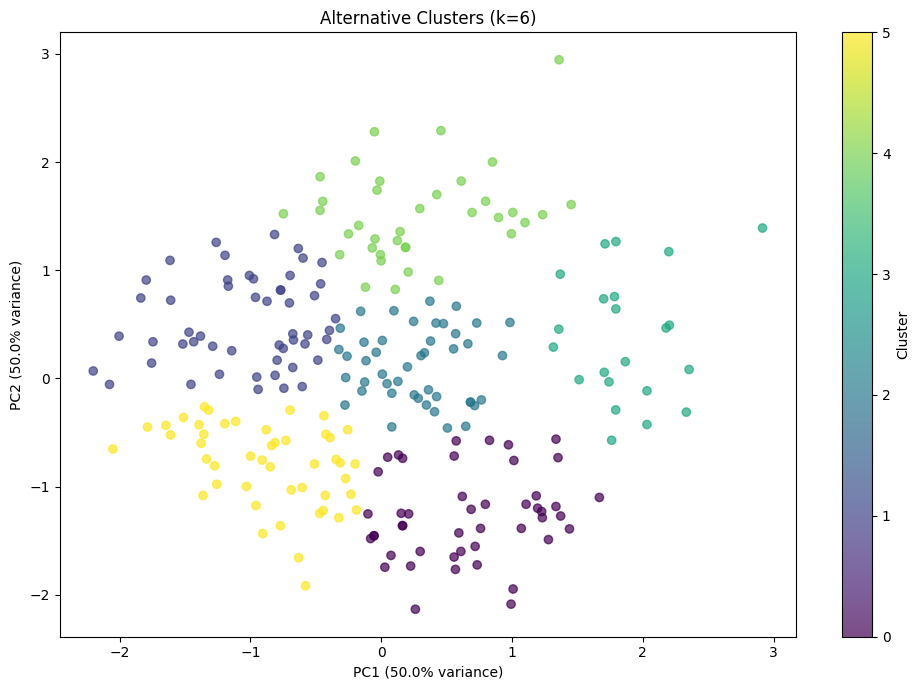

Best k for Alternative: 6
Silhouette scores: {2: 0.3397944999513976, 3: 0.36873415105992957, 4: 0.36252273562052834, 5: 0.36506218730421547, 6: 0.38391378720760144, 7: 0.3811429864210104, 8: 0.3756791241368128, 9: 0.3809404604059815, 10: 0.36787230608149213}
Correlation matrix:
              BPM   Valence
BPM      1.000000  0.000282
Valence  0.000282  1.000000

Cluster distribution:
cluster
0    47
1    52
2    45
3    22
4    37
5    47
Name: count, dtype: int64

PCA loadings:
              PC1       PC2
BPM      0.707107  0.707107
Valence  0.707107 -0.707107

Analyzing Pop playlist...


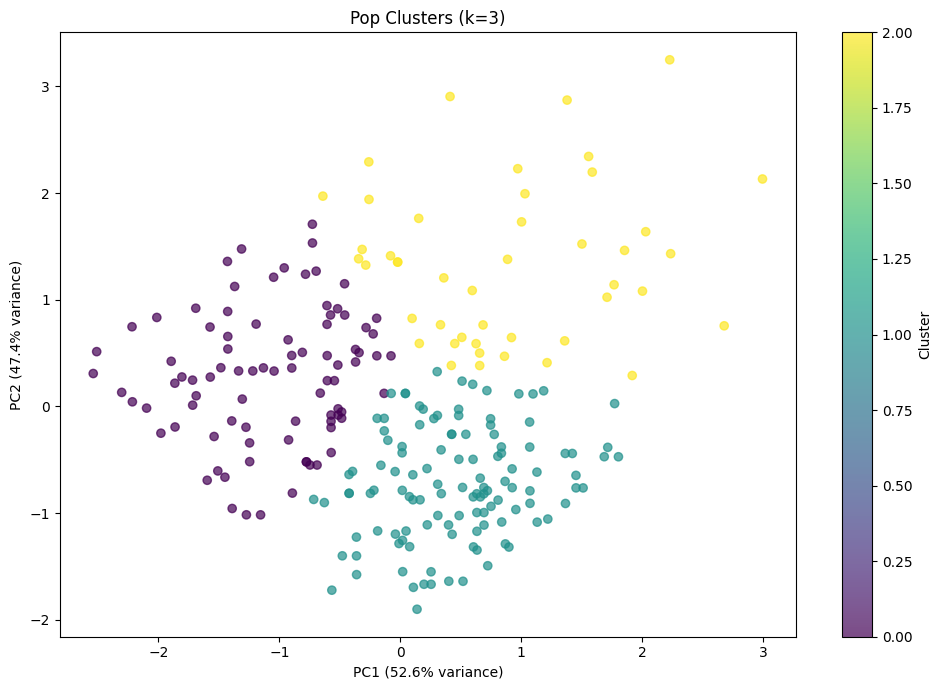

Best k for Pop: 3
Silhouette scores: {2: 0.37123729201079236, 3: 0.41361468605713364, 4: 0.39947128930497755, 5: 0.3494204621898241, 6: 0.3592679570929968, 7: 0.3606374000875468, 8: 0.3513783934553904, 9: 0.3520914752584547, 10: 0.3671745020096323}
Correlation matrix:
              BPM   Valence
BPM      1.000000  0.052703
Valence  0.052703  1.000000

Cluster distribution:
cluster
0     87
1    118
2     45
Name: count, dtype: int64

PCA loadings:
              PC1       PC2
BPM      0.707107  0.707107
Valence  0.707107 -0.707107

Analyzing Rap-R&B playlist...


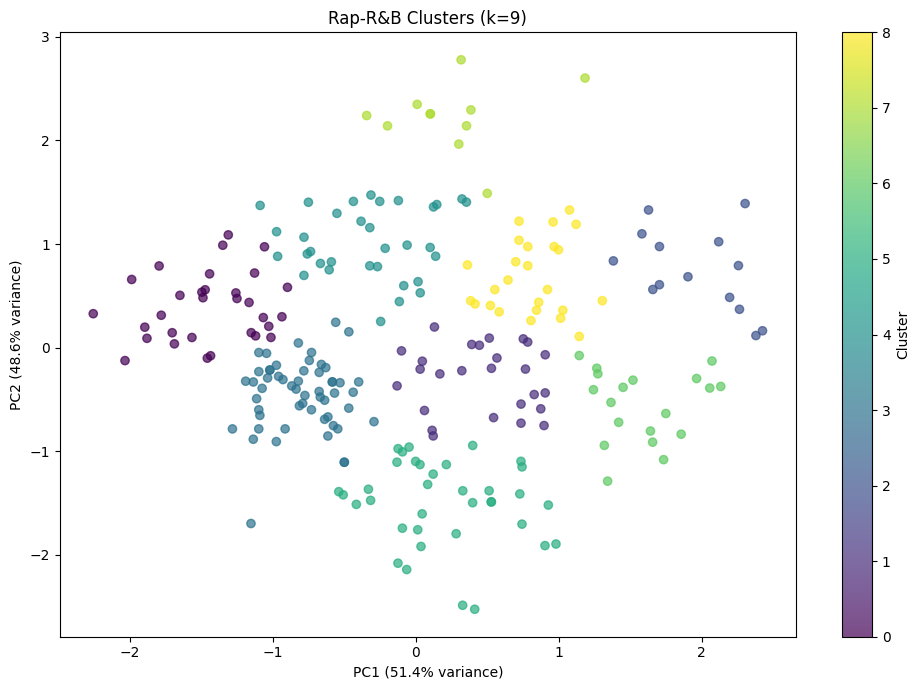

Best k for Rap-R&B: 9
Silhouette scores: {2: 0.37104036243027294, 3: 0.3923340114285761, 4: 0.40080770120998, 5: 0.3790615186193672, 6: 0.38356287757403984, 7: 0.40168355494712615, 8: 0.40191458332508695, 9: 0.4038660722792556, 10: 0.39542842262126}
Correlation matrix:
              BPM   Valence
BPM      1.000000 -0.028442
Valence -0.028442  1.000000

Cluster distribution:
cluster
0    31
1    26
2    14
3    55
4    33
5    36
6    19
7    11
8    25
Name: count, dtype: int64

PCA loadings:
              PC1       PC2
BPM      0.707107  0.707107
Valence -0.707107  0.707107

Analyzing Rock playlist...


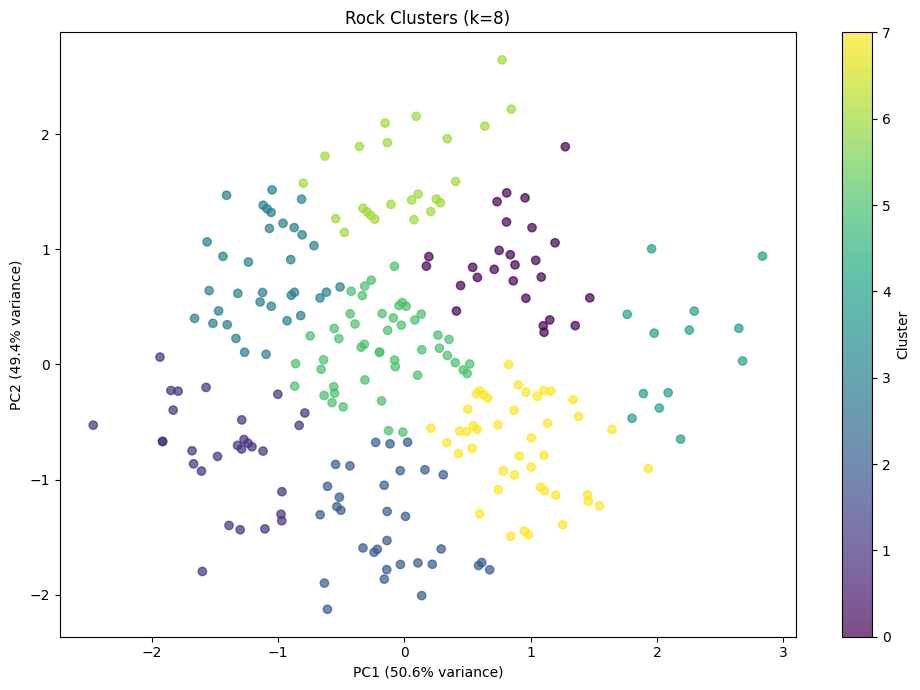

Best k for Rock: 8
Silhouette scores: {2: 0.3486924028116157, 3: 0.36974435530360733, 4: 0.3364816226900606, 5: 0.33672382557895425, 6: 0.35917104188409443, 7: 0.3756146131927625, 8: 0.3810723265644426, 9: 0.37768124265993047, 10: 0.3745892525503887}
Correlation matrix:
              BPM   Valence
BPM      1.000000  0.011326
Valence  0.011326  1.000000

Cluster distribution:
cluster
0    26
1    29
2    32
3    34
4    13
5    48
6    24
7    44
Name: count, dtype: int64

PCA loadings:
              PC1       PC2
BPM      0.707107  0.707107
Valence  0.707107 -0.707107



In [5]:
# Analyze each playlist in the library
for playlist, group in playlist_dict.items():
    print(f'Analyzing {playlist} playlist...')
    results = cluster_playlist(df_library, playlist, features=['BPM', 'Valence'])
    group['cluster'] = results['clusters']
    print(f"Best k for {playlist}: {results['best_k']}")
    print(f"Silhouette scores: {results['silhouette_scores']}")
    print(f"Correlation matrix:\n{results['correlation']}\n")
    print(f"Cluster distribution:\n{group['cluster'].value_counts().sort_index()}\n")
    print(f"PCA loadings:\n{results['pca_loadings']}\n")

### Nearest Neighbors

#### Functions

In [6]:
# 1. Define a function to get song features
def get_song_features(df_library, playlist, features, song_name, artist_name=None):
    df_playlist = df_library[df_library['Playlist'] == playlist]
    
    mask = df_playlist['Song'].str.contains(song_name, case=False, na=False)
    if artist_name:
        mask = mask & df_playlist['Artist'].str.contains(artist_name, case=False, na=False)
    
    if mask.sum() == 0:
        print(f"Couldn't find '{song_name}'" + (f" by '{artist_name}'" if artist_name else ""))
        return None
    
    row = df_playlist[mask].iloc[0]
    print(f"{row['Song']} — {row['Artist']}")
    print(f"(BPM: {row['BPM']}, Valence: {row['Valence']})")
    
    return [row[f] for f in features]


# 2. Define a function to find similar songs using KNN
def find_similar_songs(df_library, playlist, features, target, n=5):
    df_playlist = df_library[df_library['Playlist'] == playlist].copy()
    
    # Scale features
    X = df_playlist[features].dropna()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Fit KNN
    knn = NearestNeighbors(n_neighbors=n, metric='euclidean')
    knn.fit(X_scaled)
    
    # Scale the target point (with feature names to silence warning)
    target_df = pd.DataFrame([target], columns=features)
    target_scaled = scaler.transform(target_df)[0]
    
    # Get neighbors
    distances, indices = knn.kneighbors([target_scaled])
    
    # Print similar songs
    print(f"Songs near (BPM: {target[0]}, Valence: {target[1]}):\n")
    
    for i, (dist, neighbor_idx) in enumerate(zip(distances[0], indices[0])):
        neighbor_row = df_playlist.iloc[neighbor_idx]
        bpm = neighbor_row['BPM']
        valence = neighbor_row['Valence']
        print(f"{i+1}. {neighbor_row['Song']} — {neighbor_row['Artist']} (BPM: {bpm}, Valence: {valence})")
    
    # Group summary
    group_df = df_playlist.iloc[indices[0]]
    
    print(f"\n--- Group summary (n={n}) ---")
    print(f"Mean:   {group_df[features].mean().to_dict()}")
    print(f"Std:    {group_df[features].std().to_dict()}")
    print(f"Range:  {group_df[features].min().to_dict()} to {group_df[features].max().to_dict()}")
    
    return group_df

#### Results: Alternative Playlist

##### Step 1: Get songs similar for each seed song

In [7]:
# Seed Song #1: "Dissolve" by Absofacto
target_1 = get_song_features(df_library, playlist='Alternative', features=['BPM', 'Valence'], song_name='Dissolve')

Dissolve — Absofacto,NITESHIFT
(BPM: 85, Valence: 87)


In [8]:
# Group 1: Similar to "Dissolve"   
group_1 = find_similar_songs(df_library, playlist='Alternative', features=['BPM', 'Valence'], target=target_1, n=10)

Songs near (BPM: 85, Valence: 87):

1. Dissolve — Absofacto,NITESHIFT (BPM: 85, Valence: 87)
2. Take My Love and Run — Bad Suns (BPM: 92, Valence: 80)
3. Trip Switch — Nothing But Thieves (BPM: 88, Valence: 77)
4. Devil's Advocate — The Neighbourhood (BPM: 98, Valence: 86)
5. Pretty Pimpin — Kurt Vile (BPM: 91, Valence: 76)
6. Youth — Glass Animals (BPM: 96, Valence: 79)
7. home ft. WALK THE MOON — MORGXN,WALK THE MOON (BPM: 100, Valence: 84)
8. Obsession — Joywave (BPM: 102, Valence: 88)
9. Guillotine — Mansionair,NoMBe (BPM: 102, Valence: 84)
10. Kangaroo Court — Capital Cities (BPM: 100, Valence: 98)

--- Group summary (n=10) ---
Mean:   {'BPM': 95.4, 'Valence': 83.9}
Std:    {'BPM': 6.058969476000941, 'Valence': 6.488451279003334}
Range:  {'BPM': 85, 'Valence': 76} to {'BPM': 102, 'Valence': 98}


In [9]:
# Seed Song #2: "Youth" by Glass Animals
target_2 = get_song_features(df_library, playlist='Alternative', features=['BPM', 'Valence'], song_name='Youth', artist_name='Glass Animals')

Youth — Glass Animals
(BPM: 96, Valence: 79)


In [10]:
# Group #2: Similar to "Youth" by Glass Animals
group_2 = find_similar_songs(df_library, playlist='Alternative', features=['BPM', 'Valence'], target=target_2, n=10)

Songs near (BPM: 96, Valence: 79):

1. Youth — Glass Animals (BPM: 96, Valence: 79)
2. Take My Love and Run — Bad Suns (BPM: 92, Valence: 80)
3. Pretty Pimpin — Kurt Vile (BPM: 91, Valence: 76)
4. home ft. WALK THE MOON — MORGXN,WALK THE MOON (BPM: 100, Valence: 84)
5. It's A Trip! — Joywave (BPM: 98, Valence: 73)
6. Doing Good — Milky Chance (BPM: 98, Valence: 73)
7. Trip Switch — Nothing But Thieves (BPM: 88, Valence: 77)
8. Guillotine — Mansionair,NoMBe (BPM: 102, Valence: 84)
9. Devil's Advocate — The Neighbourhood (BPM: 98, Valence: 86)
10. So Tied Up — Cold War Kids,Bishop Briggs (BPM: 105, Valence: 81)

--- Group summary (n=10) ---
Mean:   {'BPM': 96.8, 'Valence': 79.3}
Std:    {'BPM': 5.202563470700446, 'Valence': 4.571651780264984}
Range:  {'BPM': 88, 'Valence': 73} to {'BPM': 105, 'Valence': 86}


In [11]:
# Seed Song #3: "Blossom" by Milky Chance
target_3 = get_song_features(df_library, playlist='Alternative', features=['BPM', 'Valence'], song_name='Blossom', artist_name='Milky Chance')

Blossom — Milky Chance
(BPM: 120, Valence: 85)


In [12]:
# Group #3: Similar to "Blossom"
group_3 = find_similar_songs(df_library, playlist='Alternative', features=['BPM', 'Valence'], target=target_3, n=10)

Songs near (BPM: 120, Valence: 85):

1. Blossom — Milky Chance (BPM: 120, Valence: 85)
2. Capricorn — Elderbrook (BPM: 121, Valence: 87)
3. Bad Habit — The Kooks (BPM: 123, Valence: 85)
4. Animals — Coast Modern (BPM: 121, Valence: 88)
5. Salt — Bad Suns (BPM: 120, Valence: 89)
6. Body Heat — Goldie Boutilier (BPM: 115, Valence: 88)
7. Troubled Man — Milky Chance (BPM: 124, Valence: 89)
8. Typical Ways — Culture Wars (BPM: 123, Valence: 91)
9. Cocoon — Milky Chance (BPM: 114, Valence: 80)
10. Too Sweet — Hozier (BPM: 117, Valence: 93)

--- Group summary (n=10) ---
Mean:   {'BPM': 119.8, 'Valence': 87.5}
Std:    {'BPM': 3.425395354310701, 'Valence': 3.5978388574871505}
Range:  {'BPM': 114, 'Valence': 80} to {'BPM': 124, 'Valence': 93}


In [13]:
# Seed Song #5: "Body Heat" by Goldie Boutilier
target_4 = get_song_features(df_library, playlist='Alternative', features=['BPM', 'Valence'], song_name='Body Heat', artist_name='Goldie Boutilier')

Body Heat — Goldie Boutilier
(BPM: 115, Valence: 88)


In [14]:
# Group #4: Similar to "Body Heat"
group_4 = find_similar_songs(df_library, playlist='Alternative', features=['BPM', 'Valence'], target=target_4, n=10)

Songs near (BPM: 115, Valence: 88):

1. Body Heat — Goldie Boutilier (BPM: 115, Valence: 88)
2. Salt — Bad Suns (BPM: 120, Valence: 89)
3. Animals — Coast Modern (BPM: 121, Valence: 88)
4. Capricorn — Elderbrook (BPM: 121, Valence: 87)
5. Blossom — Milky Chance (BPM: 120, Valence: 85)
6. Too Sweet — Hozier (BPM: 117, Valence: 93)
7. I'm Not Really Here — X Ambassadors (BPM: 109, Valence: 83)
8. Bad Habit — The Kooks (BPM: 123, Valence: 85)
9. Typical Ways — Culture Wars (BPM: 123, Valence: 91)
10. Troubled Man — Milky Chance (BPM: 124, Valence: 89)

--- Group summary (n=10) ---
Mean:   {'BPM': 119.3, 'Valence': 87.8}
Std:    {'BPM': 4.547282460742656, 'Valence': 2.9739610697593952}
Range:  {'BPM': 109, 'Valence': 83} to {'BPM': 124, 'Valence': 93}


In [15]:
# Seed Song #5: "Cowboy Gangster Politician" by Goldie Boutilier
target_5 = get_song_features(df_library, playlist='Alternative', features=['BPM', 'Valence'], song_name='Cowboy Gangster Politician', artist_name='Goldie Boutilier')

Cowboy Gangster Politician — Goldie Boutilier
(BPM: 130, Valence: 63)


In [16]:
# Group 5: Similar to "Cowboy Gangster Politician"
group_5 = find_similar_songs(df_library, playlist='Alternative', features=['BPM', 'Valence'], target=target_5, n=10)

Songs near (BPM: 130, Valence: 63):

1. Fall Over — BANKS (BPM: 130, Valence: 63)
2. Cowboy Gangster Politician — Goldie Boutilier (BPM: 130, Valence: 63)
3. Blood In The Cut — K.Flay (BPM: 130, Valence: 64)
4. The Day I Die — ISLAND (BPM: 132, Valence: 64)
5. Dirty Love — Mt. Joy (BPM: 125, Valence: 66)
6. Wasted — Rainbow Kitten Surprise (BPM: 126, Valence: 58)
7. Opening Night — Arctic Monkeys,War Child Records (BPM: 123, Valence: 60)
8. Running From My Shadow (feat. grandson) — Mike Shinoda,grandson (BPM: 122, Valence: 64)
9. East of Eden — Zella Day (BPM: 123, Valence: 58)
10. Kill Of The Night — Gin Wigmore (BPM: 126, Valence: 56)

--- Group summary (n=10) ---
Mean:   {'BPM': 126.7, 'Valence': 61.6}
Std:    {'BPM': 3.560586718193756, 'Valence': 3.3399933466334266}
Range:  {'BPM': 122, 'Valence': 56} to {'BPM': 132, 'Valence': 66}


##### Step 2: Concat songs, filter, and sort

In [17]:
# Get summary stats for target songs
targets = [target_1, target_2, target_3, target_4, target_5]
targets_df = pd.DataFrame(targets, columns=['BPM', 'Valence'])

print(f"Mean:   {targets_df.mean().to_dict()}")
print(f"Std:    {targets_df.std().to_dict()}")
print(f"Range:  {targets_df.min().to_dict()} to {targets_df.max().to_dict()}")

Mean:   {'BPM': 109.2, 'Valence': 80.4}
Std:    {'BPM': 18.322117781522966, 'Valence': 10.334408546211051}
Range:  {'BPM': 85, 'Valence': 63} to {'BPM': 130, 'Valence': 88}


In [18]:
# Combine groups and filter by target values
min_bpm = targets_df['BPM'].min()
min_valence = targets_df['Valence'].min()

knn_combined = (
    pd.concat([group_1, group_2, group_3, group_4, group_5])
    .drop_duplicates(subset='Song')
    .query('BPM >= @min_bpm and Valence >= @min_valence')
    .sort_values(['BPM', 'Valence'])
    .reset_index(drop=True)
)

# Print summary stats for the combined group
print(f"Combined Group Summary (n={len(knn_combined)}):")
print(f"Mean:   {knn_combined[['BPM', 'Valence']].mean().to_dict()}")
print(f"Std:    {knn_combined[['BPM', 'Valence']].std().to_dict()}")
print(f"Range:  {knn_combined[['BPM', 'Valence']].min().to_dict()} to {knn_combined[['BPM', 'Valence']].max().to_dict()}")

# Return knn_combined with only relevant columns
knn_combined = knn_combined[['Song', 'Artist', 'BPM', 'Valence']]
knn_combined

Combined Group Summary (n=30):
Mean:   {'BPM': 111.03333333333333, 'Valence': 80.26666666666667}
Std:    {'BPM': 14.218694186451021, 'Valence': 9.927090532315177}
Range:  {'BPM': 85, 'Valence': 63} to {'BPM': 132, 'Valence': 98}


,Song,Artist,BPM,Valence
0,Dissolve,"Absofacto,NITESHIFT",85,87
1,Trip Switch,Nothing But Thieves,88,77
2,Pretty Pimpin,Kurt Vile,91,76
3,Take My Love and Run,Bad Suns,92,80
4,Youth,Glass Animals,96,79
5,It's A Trip!,Joywave,98,73
6,Doing Good,Milky Chance,98,73
7,Devil's Advocate,The Neighbourhood,98,86
8,home ft. WALK THE MOON,"MORGXN,WALK THE MOON",100,84
9,Kangaroo Court,Capital Cities,100,98
